# 9. Autoencoders 🔄

En este notebook aprenderás los fundamentos de los autoencoders, incluyendo autoencoders simples, denoising y variacionales (VAE), con ejemplos prácticos en TensorFlow/Keras.

✨ **Highlights:**
- Autoencoder simple con visualización de reconstrucciones
- Denoising autoencoder: limpiar imágenes con ruido
- VAE: espacio latente continuo y generación de nuevos dígitos
- Comparación de error de reconstrucción entre los tres tipos

## Objetivo
- Comprender la teoría y arquitectura de los autoencoders.
- Implementar un autoencoder simple, un denoising autoencoder y un VAE.
- Visualizar reconstrucciones y el espacio latente.
- Aplicar buenas prácticas para entrenamiento eficiente.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [08 (GANs)](./08_gans.ipynb).

- Conceptos de redes neuronales y modelos generativos.

## 1. Introducción teórica

Un autoencoder comprime datos en una representación de menor dimensión y luego los reconstruye.

| Tipo | Uso principal | Característica |
|------|---------------|----------------|
| **Simple** | Reducción de dimensionalidad | Comprime y reconstruye |
| **Denoising** | Eliminación de ruido | Entrena con datos ruidosos |
| **Variacional (VAE)** | Generación de datos | Espacio latente continuo y muestreable |

## 2. Importación de librerías

In [1]:
import random
import numpy as np
import os
import logging
import time

# === Reproducibilidad ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Suprimir logs de XLA/oneDNN antes de importar TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# === Información del dispositivo ===
print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)}')
if gpus:
    for gpu in gpus:
        print(f'  ✅ {gpu.name}')
else:
    print('  ⚠️  Sin GPU — se usará CPU')
print('─' * 50)

TensorFlow: 2.21.0
GPUs disponibles: 1
  ✅ /physical_device:GPU:0
──────────────────────────────────────────────────


## 3. Autoencoder simple

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0587 - val_loss: 0.0327
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0266 - val_loss: 0.0211
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0189 - val_loss: 0.0166
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0160 - val_loss: 0.0146
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0144 - val_loss: 0.0135
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0133 - val_loss: 0.0125
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0124 - val_loss: 0.0117
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0111
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0112 - val_loss: 0.0106
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0107 - val_loss: 0.0102
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0104 - val_loss: 0.0100
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/st

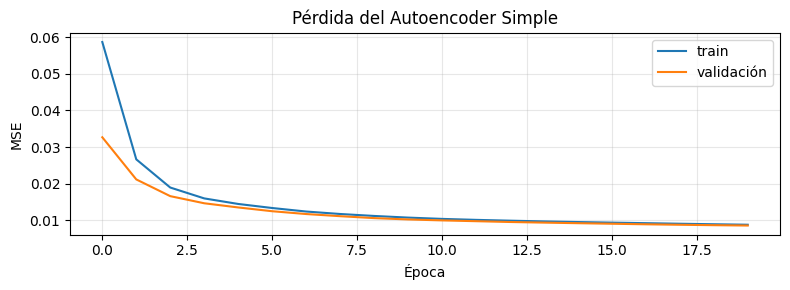

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)

encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = keras.layers.Dense(128, activation='relu')(input_img)
encoded = keras.layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = keras.layers.Dense(128, activation='relu')(encoded)
decoded = keras.layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
hist_ae = autoencoder.fit(
    X_train_flat, X_train_flat,
    epochs=20, batch_size=256, shuffle=True,
    validation_data=(X_test_flat, X_test_flat),
    callbacks=[early_stop], verbose=1)
t_ae = time.time() - start

mse_ae = autoencoder.evaluate(X_test_flat, X_test_flat, verbose=0)
print(f'\n✅ Autoencoder simple | MSE test: {mse_ae:.6f} | Tiempo: {t_ae:.1f}s')

# Curva de entrenamiento
plt.figure(figsize=(8, 3))
plt.plot(hist_ae.history['loss'], label='train')
plt.plot(hist_ae.history['val_loss'], label='validación')
plt.title('Pérdida del Autoencoder Simple')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualización de reconstrucciones

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


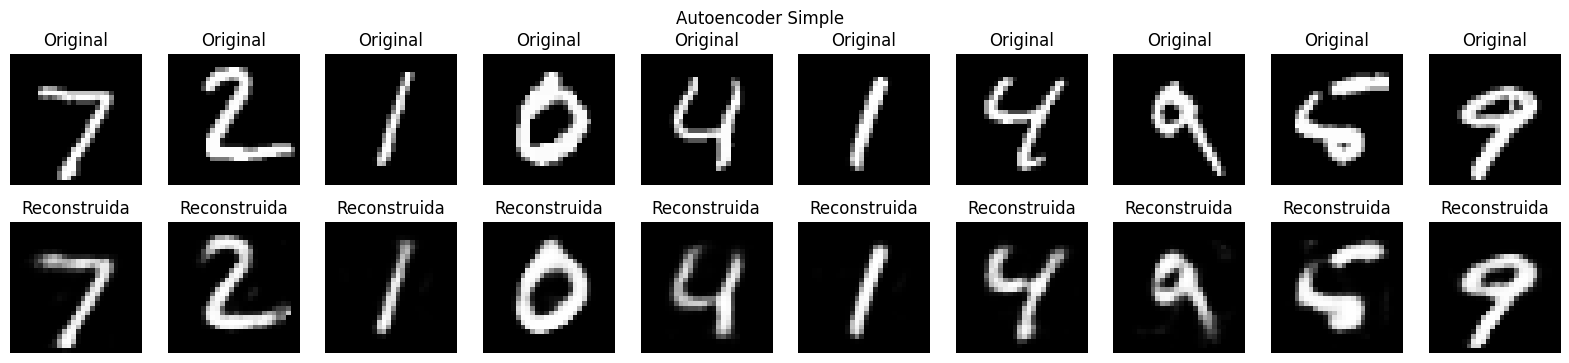

In [3]:
decoded_imgs = autoencoder.predict(X_test_flat)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title('Original')
    plt.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstruida')
    plt.axis('off')
plt.suptitle('Autoencoder Simple')
plt.show()

## 4. Denoising Autoencoder

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0644 - val_loss: 0.0410
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0359 - val_loss: 0.0317
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0303 - val_loss: 0.0285
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0278 - val_loss: 0.0266
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0261 - val_loss: 0.0251
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0248 - val_loss: 0.0240
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0239 - val_loss: 0.0233
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0232 - val_loss: 0.0227
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0228 - val_loss: 0.0224
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0224 - val_loss: 0.0220

✅ Denoising AE | MSE test: 0.022001 | Tiempo: 24.1s
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


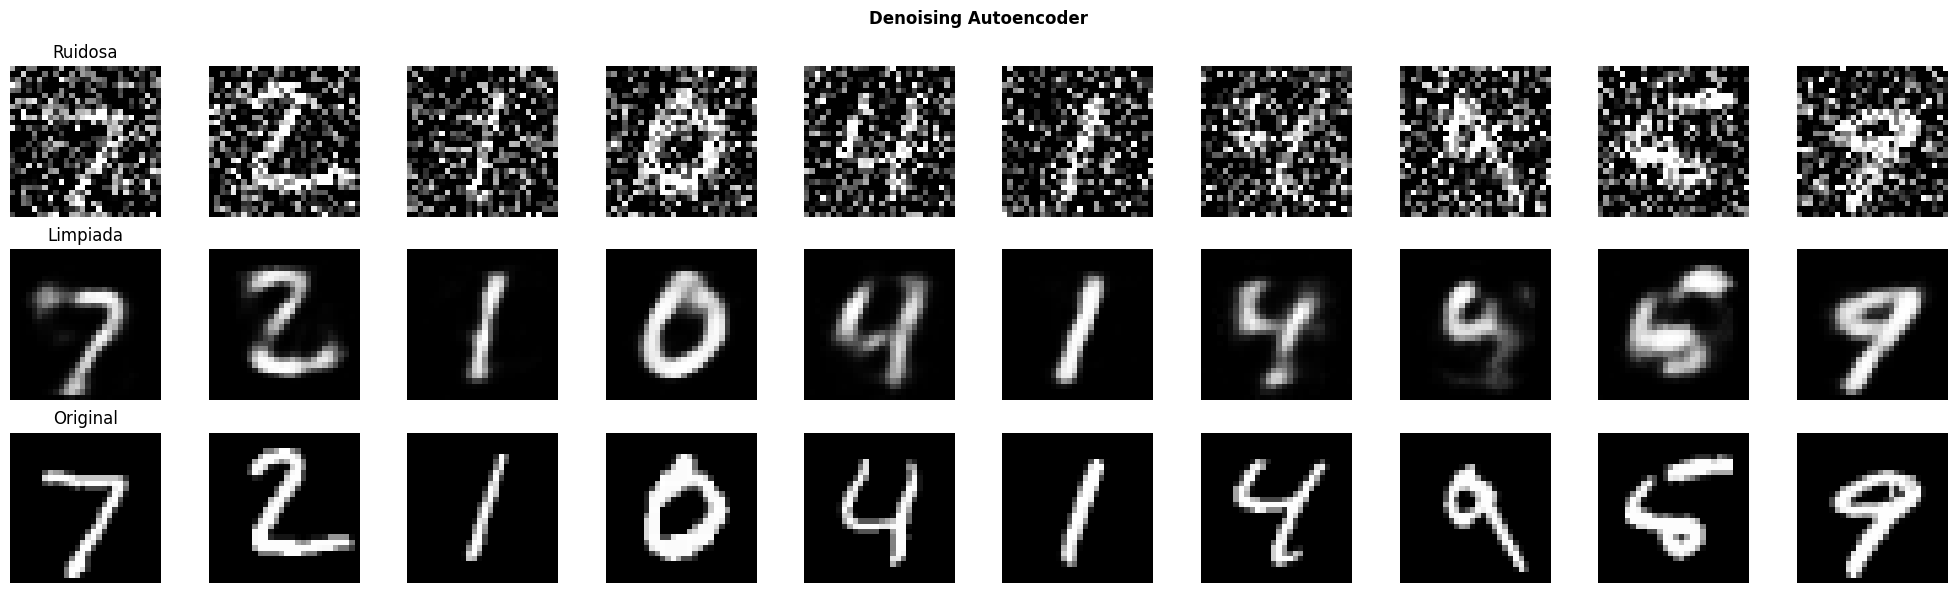

In [4]:
noise_factor = 0.5
X_train_noisy = np.clip(X_train_flat + noise_factor * np.random.normal(0, 1, X_train_flat.shape), 0., 1.)
X_test_noisy = np.clip(X_test_flat + noise_factor * np.random.normal(0, 1, X_test_flat.shape), 0., 1.)

denoising_ae = keras.models.clone_model(autoencoder)
denoising_ae.compile(optimizer='adam', loss='mse')

early_stop_dn = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
hist_dn = denoising_ae.fit(
    X_train_noisy, X_train_flat,
    epochs=10, batch_size=256, shuffle=True,
    validation_data=(X_test_noisy, X_test_flat),
    callbacks=[early_stop_dn], verbose=1)
t_dn = time.time() - start

mse_dn = denoising_ae.evaluate(X_test_noisy, X_test_flat, verbose=0)
print(f'\n✅ Denoising AE | MSE test: {mse_dn:.6f} | Tiempo: {t_dn:.1f}s')

n = 10
decoded_noisy = denoising_ae.predict(X_test_noisy)

plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Ruidosa') if i == 0 else None
    plt.axis('off')
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Limpiada') if i == 0 else None
    plt.axis('off')
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(X_test[i], cmap='gray')
    plt.title('Original') if i == 0 else None
    plt.axis('off')
plt.suptitle('Denoising Autoencoder', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Variational Autoencoder (VAE)

El VAE aprende un espacio latente **continuo y muestreable**, permitiendo generar nuevos datos interpolando en el espacio latente.

In [5]:
latent_dim = 2

class Sampling(keras.layers.Layer):
    """Muestreo reparametrizado: z = mu + sigma * epsilon."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean))
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

class VAE(keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.enc1          = keras.layers.Dense(256, activation='relu')
        self.z_mean_layer  = keras.layers.Dense(latent_dim, name='z_mean')
        self.z_log_var_layer = keras.layers.Dense(latent_dim, name='z_log_var')
        self.sampling      = Sampling()
        self.dec1          = keras.layers.Dense(256, activation='relu')
        self.dec_out       = keras.layers.Dense(784, activation='sigmoid')

    def encode(self, x):
        h = self.enc1(x)
        return self.z_mean_layer(h), self.z_log_var_layer(h)

    def decode(self, z):
        return self.dec_out(self.dec1(z))

    def call(self, x, training=False):
        z_mean, z_log_var = self.encode(x)
        z = self.sampling([z_mean, z_log_var])
        x_decoded = self.decode(z)
        # KL divergence añadida como pérdida auxiliar (add_loss sólo funciona en subclassed models)
        kl_loss = -0.5 * keras.ops.mean(
            keras.ops.sum(
                1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var),
                axis=-1
            )
        )
        self.add_loss(kl_loss)
        return x_decoded

vae = VAE(latent_dim)
vae.compile(optimizer='adam', loss='binary_crossentropy')

early_stop_vae = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
hist_vae = vae.fit(
    X_train_flat, X_train_flat,
    epochs=15, batch_size=256,
    validation_data=(X_test_flat, X_test_flat),
    callbacks=[early_stop_vae], verbose=1)
t_vae = time.time() - start
print(f'\n✅ VAE | Tiempo: {t_vae:.1f}s')

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.3556 - val_loss: 0.2703
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2674 - val_loss: 0.2651
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2646 - val_loss: 0.2637
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2637 - val_loss: 0.2633
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2634 - val_loss: 0.2630
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2630 - val_loss: 0.2628
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2630 - val_loss: 0.2627
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2630 - val_loss: 0.2627
Epoch 12/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/st

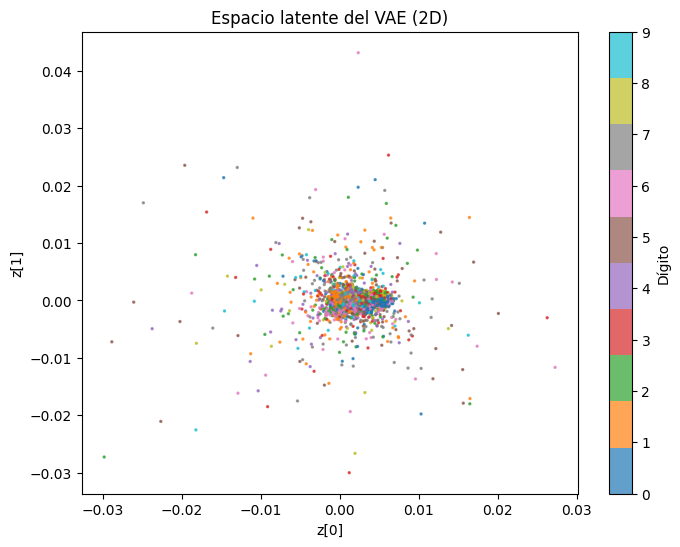

In [6]:
# Visualizar espacio latente
z_test_mean, _ = vae.encode(X_test_flat)
z_test = z_test_mean.numpy()

plt.figure(figsize=(8, 6))
plt.scatter(z_test[:, 0], z_test[:, 1], c=y_test, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(label='Dígito')
plt.title('Espacio latente del VAE (2D)')
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.show()

## 5b. Comparación de los tres autoencoders

            Modelo  MSE test (reconstrucción)  Tiempo entrenamiento (s)  Espacio latente (dims) Genera nuevos datos
Autoencoder simple                   0.008548                      50.3                      32                  No
      Denoising AE                   0.022001                      24.1                      32                  No
               VAE                   0.067540                      46.3                       2                  Sí


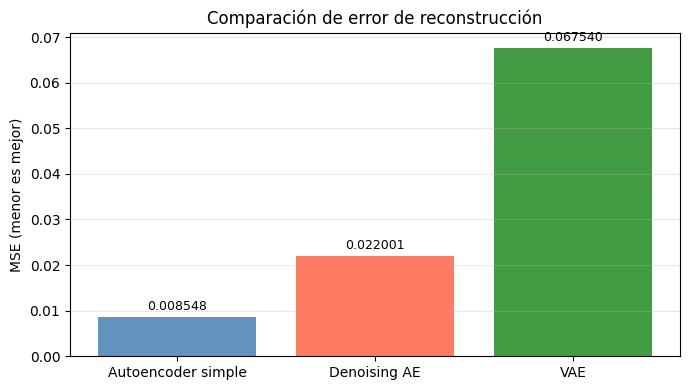


💡 El VAE tiene MSE mayor porque optimiza también la regularización KL — 
   el espacio latente más estructurado compensa el ligero aumento en reconstrucción.


In [7]:
import pandas as pd

# Reconstrucción VAE en datos limpios
mse_vae_test = np.mean((vae.predict(X_test_flat, verbose=0) - X_test_flat) ** 2)

comparison = pd.DataFrame({
    'Modelo': ['Autoencoder simple', 'Denoising AE', 'VAE'],
    'MSE test (reconstrucción)': [mse_ae, mse_dn, mse_vae_test],
    'Tiempo entrenamiento (s)': [round(t_ae, 1), round(t_dn, 1), round(t_vae, 1)],
    'Espacio latente (dims)': [encoding_dim, encoding_dim, latent_dim],
    'Genera nuevos datos': ['No', 'No', 'Sí'],
})
print(comparison.to_string(index=False))

# Gráfico comparativo de MSE
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(comparison['Modelo'], comparison['MSE test (reconstrucción)'],
              color=['steelblue', 'tomato', 'forestgreen'], alpha=0.85)
ax.bar_label(bars, fmt='%.6f', padding=3, fontsize=9)
ax.set_ylabel('MSE (menor es mejor)')
ax.set_title('Comparación de error de reconstrucción')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n💡 El VAE tiene MSE mayor porque optimiza también la regularización KL — ')
print('   el espacio latente más estructurado compensa el ligero aumento en reconstrucción.')

### Recomendaciones prácticas

| Aspecto | Recomendación |
|---------|---------------|
| **Espacio latente** | Empieza con `encoding_dim` = 32; reduce si la reconstrucción es buena de todas formas |
| **EarlyStopping** | Usar `patience=3-5` para evitar sobreajuste y acelerar búsqueda |
| **Denoising** | Incrementar `noise_factor` gradualmente (0.1 → 0.5) para evaluar robustez |
| **VAE** | Para generación, usar `latent_dim` = 2 (visualización) o 8-64 (calidad) |
| **Activación salida** | `sigmoid` para datos en [0,1]; `tanh` para datos centrados |
| **Evaluación** | Siempre visualizar reconstrucciones; MSE solo no dice todo |
| **Arquitectura conv** | Usar Conv2D/Conv2DTranspose para imágenes — mayor calidad que Dense |

> 💡 **Truco:** Para el VAE, el peso de la pérdida KL (`beta`) controla el equilibrio entre reconstrucción y regularización. Un `beta > 1` fuerza mayor disentanglement (beta-VAE).

## 6. Discusión y Conclusiones

**¿Qué aprendimos?**

- Los autoencoders aprenden representaciones comprimidas (espacio latente) sin etiquetas — son modelos **no supervisados**.
- El **autoencoder simple** minimiza la distancia entre entrada y reconstrucción; ideal para reducción de dimensionalidad.
- El **denoising autoencoder** aprende a filtrar ruido entrenando con pares ruidoso→limpio; produce representaciones más robustas.
- El **VAE** impone una distribución Gaussiana sobre el espacio latente, lo que permite **muestrear y generar nuevos datos**; el costo es un ligero aumento del MSE de reconstrucción.
- **EarlyStopping** evitó el sobreajuste y aceleró el entrenamiento en todos los modelos.
- La **comparación de MSE** confirmó que el VAE sacrifica un poco de reconstrucción fiel para ganar estructura latente muestreable.

**Para llevar:**
- Para detección de anomalías: usa un autoencoder simple y marca como anomalía lo que tenga alto MSE de reconstrucción.
- Para generación: VAE (explicable) o GAN (mayor realismo).
- Para imágenes reales: siempre preferir arquitecturas convolucionales (Conv2D + Conv2DTranspose).

En el siguiente notebook exploraremos **clustering y reducción de dimensionalidad** con scikit-learn.

## 7. Ejercicios Propuestos

1. **Ejercicio 1:** Cambia `encoding_dim` a 8, 16 y 64. ¿Cómo afecta la calidad de reconstrucción?

2. **Ejercicio 2:** Usa el VAE para generar nuevos dígitos muestreando puntos del espacio latente.

3. **Ejercicio 3:** Implementa un autoencoder convolucional (usando Conv2D y Conv2DTranspose).

4. **Ejercicio 4 (Avanzado):** Usa un VAE condicional (CVAE) que genere dígitos específicos.

## 8. Referencias y Recursos

- [TensorFlow Autoencoder Tutorial](https://www.tensorflow.org/tutorials/generative/autoencoder)
- [VAE Tutorial - Keras](https://keras.io/examples/generative/vae/)
- Kingma & Welling (2014). *Auto-Encoding Variational Bayes.*

---

📎 **Notebook anterior:** [08. Redes Generativas (GANs)](./08_gans.ipynb)  
📎 **Notebook siguiente:** [10. Clustering y Reducción de Dimensionalidad](./10_clustering_reduccion_dimensionalidad.ipynb)